# Sinkhorn from scratch

This notebook serves as a test to the implementation of the numerical OT solver.

## Imports and project setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parents[0]
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from baselines import exact_ot_1d_sorting, exact_ot_lp

from core import (
    normalize_histogram,
    make_grid_1d,
    make_grid_2d,
    squared_euclidean_cost,
    sinkhorn,
    sinkhorn_log,
)

np.random.seed(0)

ETA = 1e-8
EPS_GRID = [0.002, 0.005, 0.01, 0.02, 0.05]

## Toy distributions

This section will define a few hand-made histograms for validation:
- shifted unimodal 1D histograms
- tiny 2D histograms on a small support

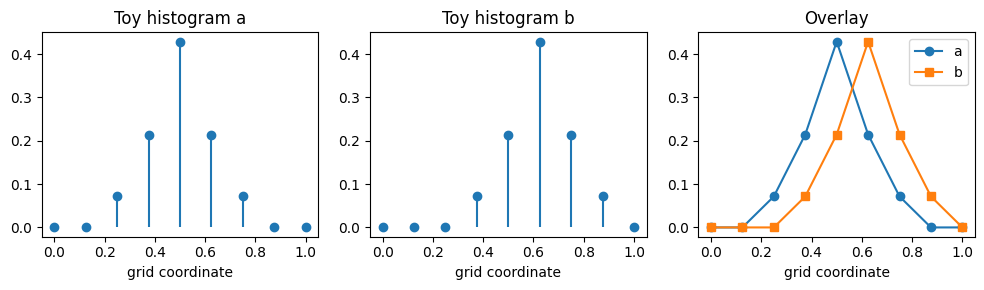

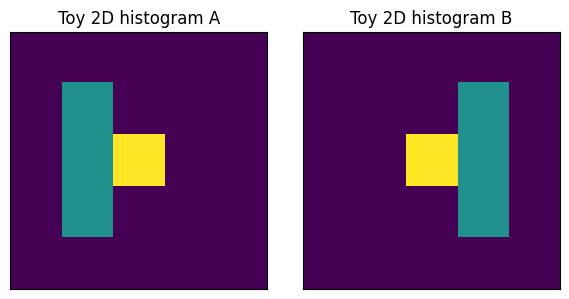

In [4]:
# Example A: 1D shifted unimodal histograms on a common grid
x = make_grid_1d(9, normalize=True)
raw_a = np.array([0, 0, 1, 3, 6, 3, 1, 0, 0], dtype=np.float64)
raw_b = np.array([0, 0, 0, 1, 3, 6, 3, 1, 0], dtype=np.float64)
a_1d = normalize_histogram(raw_a, eta=ETA)
b_1d = normalize_histogram(raw_b, eta=ETA)
C_1d_toy = squared_euclidean_cost(x)

# Example B: tiny 2D histograms on a 5x5 grid
grid_2d_small = make_grid_2d(5, 5, normalize=True)
A_img = np.zeros((5, 5), dtype=np.float64)
B_img = np.zeros((5, 5), dtype=np.float64)
A_img[1:4, 1] = 1.0
A_img[2, 2] = 2.0
B_img[1:4, 3] = 1.0
B_img[2, 2] = 2.0
a_2d = normalize_histogram(A_img, eta=ETA).ravel()
b_2d = normalize_histogram(B_img, eta=ETA).ravel()
C_2d_toy = squared_euclidean_cost(grid_2d_small)

###

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].stem(x.ravel(), a_1d, basefmt=" ")
axes[0].set_title("Toy histogram a")
axes[1].stem(x.ravel(), b_1d, basefmt=" ")
axes[1].set_title("Toy histogram b")
axes[2].plot(x.ravel(), a_1d, marker="o", label="a")
axes[2].plot(x.ravel(), b_1d, marker="s", label="b")
axes[2].legend()
axes[2].set_title("Overlay")
for ax in axes:
    ax.set_xlabel("grid coordinate")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(A_img, interpolation="nearest")
axes[0].set_title("Toy 2D histogram A")
axes[1].imshow(B_img, interpolation="nearest")
axes[1].set_title("Toy 2D histogram B")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## Exact baselines on tiny problems

This section will compare:
- exact 1D OT via sorting 
- exact OT via linear programming 

In [4]:
# Tiny 1D example on a common normalized grid
x = make_grid_1d(6, normalize=True).ravel()
y = make_grid_1d(6, normalize=True).ravel()

a_raw = np.array([0.0, 0.0, 1.0, 3.0, 1.0, 0.0], dtype=np.float64)
b_raw = np.array([0.0, 2.0, 2.0, 1.0, 0.0, 0.0], dtype=np.float64)

a = normalize_histogram(a_raw, eta=0.0).ravel()
b = normalize_histogram(b_raw, eta=0.0).ravel()

out_1d = exact_ot_1d_sorting(a, b, x, y, p=2)

print("Exact 1D OT cost:", out_1d["cost"])
print("Row sums close to a:", np.allclose(out_1d["plan"].sum(axis=1), a))
print("Col sums close to b:", np.allclose(out_1d["plan"].sum(axis=0), b))
print("Plan shape:", out_1d["plan"].shape)

Exact 1D OT cost: 0.06400000000000002
Row sums close to a: True
Col sums close to b: True
Plan shape: (6, 6)


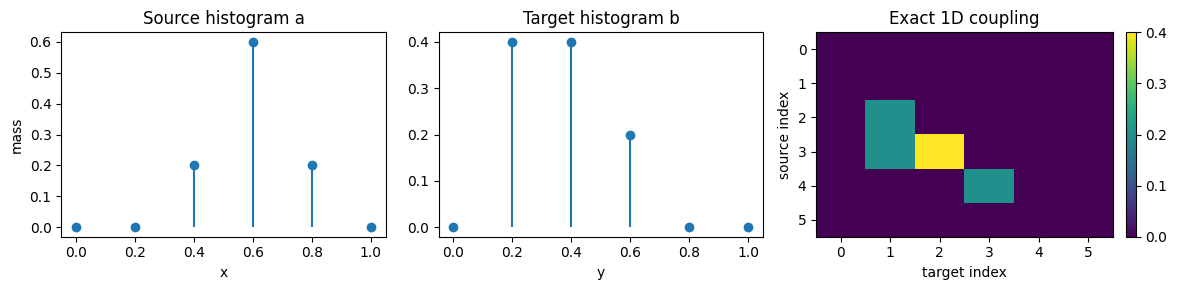

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].stem(x, a, basefmt=" ")
axes[0].set_title("Source histogram a")
axes[0].set_xlabel("x")
axes[0].set_ylabel("mass")

axes[1].stem(y, b, basefmt=" ")
axes[1].set_title("Target histogram b")
axes[1].set_xlabel("y")

im = axes[2].imshow(out_1d["plan"], aspect="auto")
axes[2].set_title("Exact 1D coupling")
axes[2].set_xlabel("target index")
axes[2].set_ylabel("source index")
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [6]:
C_1d = squared_euclidean_cost(x)
out_lp = exact_ot_lp(a, b, C_1d)

print("LP success:", out_lp["success"])
print("LP cost:", out_lp["cost"])
print("1D sorting cost:", out_1d["cost"])
print("Absolute difference:", abs(out_lp["cost"] - out_1d["cost"]))
print("Row residual L1:", out_lp["row_residual_l1"])
print("Col residual L1:", out_lp["col_residual_l1"])

LP success: True
LP cost: 0.06400000000000004
1D sorting cost: 0.06400000000000002
Absolute difference: 2.7755575615628914e-17
Row residual L1: 1.1102230246251565e-16
Col residual L1: 0.0


In [5]:
grid_2d = make_grid_2d(3, 3, normalize=True)
C_2d = squared_euclidean_cost(grid_2d)

a2_raw = np.array([
    0.0, 0.0, 0.0,
    0.0, 3.0, 0.0,
    0.0, 1.0, 0.0,
], dtype=np.float64)

b2_raw = np.array([
    0.0, 0.0, 1.0,
    0.0, 2.0, 0.0,
    0.0, 1.0, 0.0,
], dtype=np.float64)

a2 = normalize_histogram(a2_raw, eta=0.0).ravel()
b2 = normalize_histogram(b2_raw, eta=0.0).ravel()

out_lp_2d = exact_ot_lp(a2, b2, C_2d)

print("2D LP success:", out_lp_2d["success"])
print("2D LP cost:", out_lp_2d["cost"])
print("Row residual L1:", out_lp_2d["row_residual_l1"])
print("Col residual L1:", out_lp_2d["col_residual_l1"])

2D LP success: True
2D LP cost: 0.125
Row residual L1: 0.0
Col residual L1: 0.0


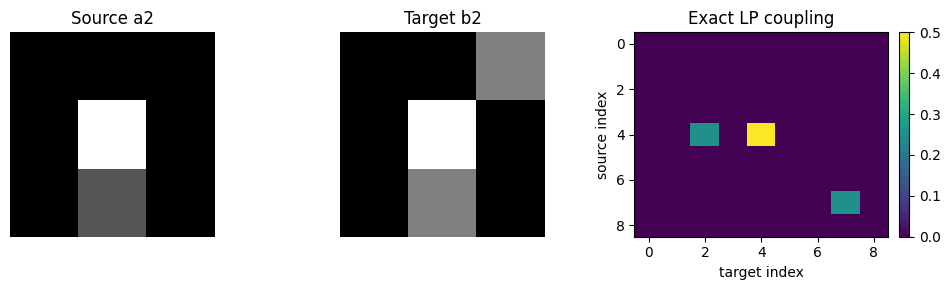

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].imshow(a2.reshape(3, 3), cmap="gray")
axes[0].set_title("Source a2")
axes[0].axis("off")

axes[1].imshow(b2.reshape(3, 3), cmap="gray")
axes[1].set_title("Target b2")
axes[1].axis("off")

im = axes[2].imshow(out_lp_2d["plan"], aspect="auto")
axes[2].set_title("Exact LP coupling")
axes[2].set_xlabel("target index")
axes[2].set_ylabel("source index")
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Sinkhorn from scratch

In [9]:
x = make_grid_1d(6, normalize=True).ravel()
y = make_grid_1d(6, normalize=True).ravel()

a_raw = np.array([0.0, 0.0, 1.0, 3.0, 1.0, 0.0], dtype=np.float64)
b_raw = np.array([0.0, 2.0, 2.0, 1.0, 0.0, 0.0], dtype=np.float64)

a = normalize_histogram(a_raw, eta=0.0).ravel()
b = normalize_histogram(b_raw, eta=0.0).ravel()

C_1d = squared_euclidean_cost(x)

out_exact = exact_ot_1d_sorting(a, b, x, y, p=2)
print("Exact 1D OT cost:", out_exact["cost"])

eps_values = [0.05, 0.02, 0.01]
results_std = {}

for eps in eps_values:
    out = sinkhorn(a, b, C_1d, eps=eps, max_iter=5000, tol=1e-6)
    results_std[eps] = out
    print(
        f"eps={eps:>6} | cost={out['cost']:.8f} | "
        f"row_res={out['row_residual_l1']:.2e} | "
        f"col_res={out['col_residual_l1']:.2e} | "
        f"iters={out['n_iter']} | converged={out['converged']}"
    )

Exact 1D OT cost: 0.06400000000000002
eps=  0.05 | cost=0.07555877 | row_res=5.04e-11 | col_res=5.55e-17 | iters=20 | converged=True
eps=  0.02 | cost=0.06719567 | row_res=3.96e-08 | col_res=8.33e-17 | iters=40 | converged=True
eps=  0.01 | cost=0.06441711 | row_res=6.45e-07 | col_res=5.55e-17 | iters=180 | converged=True


In [10]:
results_log = {}

for eps in eps_values:
    out = sinkhorn_log(a, b, C_1d, eps=eps, max_iter=5000, tol=1e-6)
    results_log[eps] = out
    print(
        f"[log] eps={eps:>6} | cost={out['cost']:.8f} | "
        f"row_res={out['row_residual_l1']:.2e} | "
        f"col_res={out['col_residual_l1']:.2e} | "
        f"iters={out['n_iter']} | converged={out['converged']}"
    )

[log] eps=  0.05 | cost=0.07555877 | row_res=5.04e-11 | col_res=5.55e-17 | iters=20 | converged=True
[log] eps=  0.02 | cost=0.06719567 | row_res=3.96e-08 | col_res=3.89e-16 | iters=40 | converged=True
[log] eps=  0.01 | cost=0.06441711 | row_res=6.45e-07 | col_res=7.22e-16 | iters=180 | converged=True


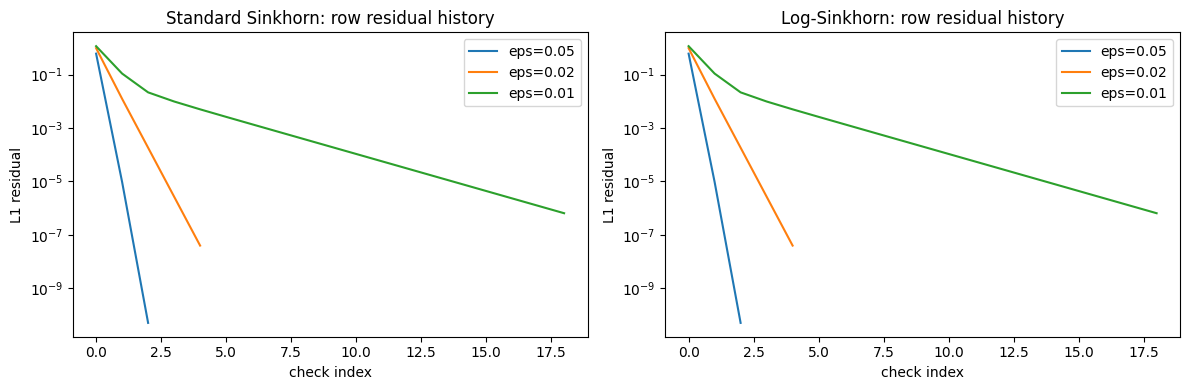

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for eps, out in results_std.items():
    axes[0].plot(out["row_residual_history"], label=f"eps={eps}")
axes[0].set_title("Standard Sinkhorn: row residual history")
axes[0].set_xlabel("check index")
axes[0].set_ylabel("L1 residual")
axes[0].set_yscale("log")
axes[0].legend()

for eps, out in results_log.items():
    axes[1].plot(out["row_residual_history"], label=f"eps={eps}")
axes[1].set_title("Log-Sinkhorn: row residual history")
axes[1].set_xlabel("check index")
axes[1].set_ylabel("L1 residual")
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.show()

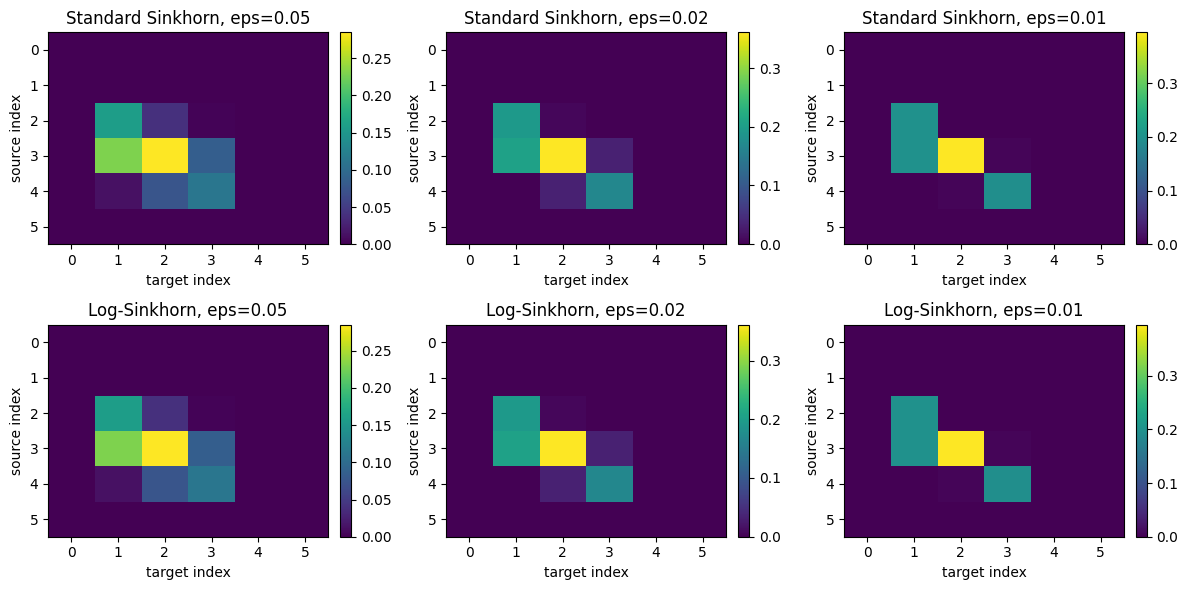

In [12]:
fig, axes = plt.subplots(2, len(eps_values), figsize=(4 * len(eps_values), 6))

for k, eps in enumerate(eps_values):
    im0 = axes[0, k].imshow(results_std[eps]["plan"], aspect="auto")
    axes[0, k].set_title(f"Standard Sinkhorn, eps={eps}")
    axes[0, k].set_xlabel("target index")
    axes[0, k].set_ylabel("source index")
    plt.colorbar(im0, ax=axes[0, k], fraction=0.046, pad=0.04)

    im1 = axes[1, k].imshow(results_log[eps]["plan"], aspect="auto")
    axes[1, k].set_title(f"Log-Sinkhorn, eps={eps}")
    axes[1, k].set_xlabel("target index")
    axes[1, k].set_ylabel("source index")
    plt.colorbar(im1, ax=axes[1, k], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()